#### Cifar-10_baseline
---

In [1]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import platform


# OS에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # macOS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')


# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 랜덤성 고정
keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [2]:
# CIFAR-10 데이터 로드
from keras.datasets import cifar10

(x_train, y_train_raw), (x_test, y_test_raw) = cifar10.load_data()
y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

In [3]:
# 학습, 검증 데이터 나누기
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    x_train, y_train, random_state=42, shuffle=True, stratify=y_train
)

In [4]:
print(train_input.shape, train_target.shape, val_input.shape, val_target.shape)

(37500, 32, 32, 3) (37500,) (12500, 32, 32, 3) (12500,)


In [5]:
# 직접 만든 CNN용: 0~1 스케일링
train_scaled = train_input.astype("float32") / 255.0
val_scaled = val_input.astype("float32") / 255.0
test_scaled = x_test.astype("float32") / 255.0

# 전이학습용: 0~255 원본 범위 유지
train_transfer = train_input.astype("float32")
val_transfer = val_input.astype("float32")
test_transfer = x_test.astype("float32")

#### 내 모델
---

In [6]:
cnn_inputs = keras.Input(shape=(32,32,3))               # 입력층

# Conv 1
cnn_x = keras.layers.Conv2D(16, 3, padding='same')(cnn_inputs)
cnn_x = keras.layers.BatchNormalization()(cnn_x)
cnn_x = keras.layers.Activation('relu')(cnn_x)
cnn_x = keras.layers.MaxPool2D(2)(cnn_x)

# Conv 2
cnn_x = keras.layers.Conv2D(32, 3, padding='same')(cnn_x)
cnn_x = keras.layers.BatchNormalization()(cnn_x)
cnn_x = keras.layers.Activation('relu')(cnn_x)
cnn_x = keras.layers.MaxPool2D(2)(cnn_x)

# Conv 3
cnn_x = keras.layers.Conv2D(64, 3, padding='same')(cnn_x)
cnn_x = keras.layers.BatchNormalization()(cnn_x)
cnn_x = keras.layers.Activation('relu')(cnn_x)
cnn_x = keras.layers.MaxPool2D(2)(cnn_x)

# Classifier
# Flatten
cnn_x = keras.layers.Flatten()(cnn_x)

# Dense 1
cnn_x = keras.layers.Dense(256, activation='relu')(cnn_x)

# Dropout 1
cnn_x = keras.layers.Dropout(0.3)(cnn_x)

# Dense 2
cnn_x = keras.layers.Dense(128, activation='relu')(cnn_x)

# Dropout 2
cnn_x = keras.layers.Dropout(0.2)(cnn_x)

# Dense 3
cnn_x = keras.layers.Dense(32, activation='relu')(cnn_x)

# 출력층
cnn_outputs = keras.layers.Dense(10, activation='softmax')(cnn_x)

model1 = keras.Model(inputs=cnn_inputs,
                     outputs=cnn_outputs,
                     name="custom_cnn_model")


In [7]:
# learning_rate
optimizer_tuned = keras.optimizers.Adam(learning_rate=0.00025)

model1.compile(optimizer=optimizer_tuned,
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'], jit_compile=False

)

model1.summary()

Model: "custom_cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,786 (1.24 MB)

 Trainable params: 323,562 (1.23 MB)

 Non-trainable params: 224 (896.00 B)

In [8]:
checkpoint1 = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', monitor='val_loss', save_best_only=True)
early_stopping1 = keras.callbacks.EarlyStopping(patience=3, monitor='val_loss', restore_best_weights=True)

history1 = model1.fit(
    train_scaled, train_target,
    callbacks=[checkpoint1, early_stopping1],
    epochs=30,
    batch_size=64,
    validation_data=(val_scaled, val_target)
)

Epoch 1/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3537 - loss: 1.7533 - val_accuracy: 0.4196 - val_loss: 1.5587
Epoch 2/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4920 - loss: 1.3928 - val_accuracy: 0.5334 - val_loss: 1.2793
Epoch 3/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5543 - loss: 1.2336 - val_accuracy: 0.5509 - val_loss: 1.2541
Epoch 4/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5950 - loss: 1.1278 - val_accuracy: 0.6000 - val_loss: 1.0980
Epoch 5/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6310 - loss: 1.0395 - val_accuracy: 0.6250 - val_loss: 1.0541
Epoch 6/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6530 - loss: 0.9737 - val_accuracy: 0.6546 - val_loss: 0.9808
Epoch 7/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6745 - loss: 0.9158 - val_accuracy: 0.6534 - val_loss: 1.0031
Epoch 8/30
586/586 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6942 - loss: 0.8627 - val_acc

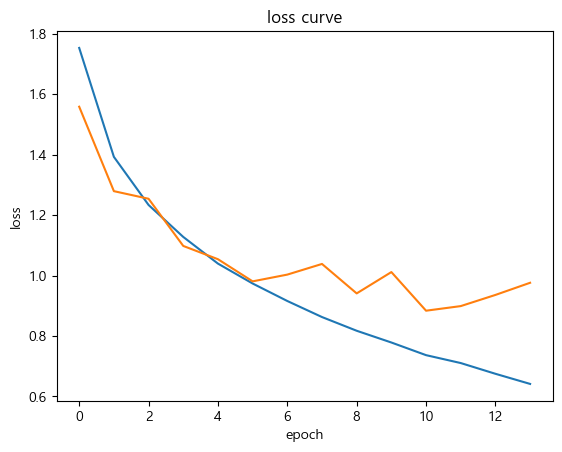

In [9]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss curve')
plt.show()

#### 전이학습
---

In [10]:
from keras.applications import MobileNetV3Small

# 전이학습 base model
transfer_base = MobileNetV3Small(
    input_shape=(96,96, 3),
    include_top=False,          # top Dense 제외
    weights='imagenet',          # imagenet에서 학습된 가중치 사용
    include_preprocessing=True
)

# 사전학습된 부분은 일단 얼림
transfer_base.trainable = False

# Funcitional API로 전이학습 모델 구성
transfer_inputs = keras.Input(shape=(32,32,3), name="transfer_input")

# CIFAR10 데이터 리사이즈
transfer_x = keras.layers.Resizing(96,96)(transfer_inputs)

# 사전학습 모델 통과
transfer_x = transfer_base(transfer_x, training=False)

# Classifier Head
# 전이학습 모델의 convolution 결과는 보통 (batch, height, width, channels) 형태
# Flatten()으로 펴면 파라미터 수가 너무 커짐. 채널 평균만 뽑아서 가볍게
transfer_x = keras.layers.GlobalAveragePooling2D()(transfer_x)
transfer_x = keras.layers.Dense(128, activation='relu')(transfer_x)
transfer_x = keras.layers.Dropout(0.3)(transfer_x)

transfer_outputs = keras.layers.Dense(10, activation='softmax',
                name="transfer_output")(transfer_x)

transfer_model = keras.Model(inputs=transfer_inputs,
                             outputs=transfer_outputs,
                             name="mobilenetv3small_transfer_model")

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

transfer_model.summary()

d:\study-flat\dl3\.venv\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3small_transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transfer_input (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 3, 3, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_output (Dense)         │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,266 (3.87 MB)

 Trainable params: 75,146 (293.54 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [11]:
checkpoint2 = keras.callbacks.ModelCheckpoint(
    'best-transfer-model.keras',
    monitor='val_loss',
    save_best_only=True
)

early_stopping2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = transfer_model.fit(
    train_transfer, train_target,
    epochs=20,
    batch_size=64,
    validation_data=(val_transfer, val_target),
    callbacks=[checkpoint2, early_stopping2]
)

Epoch 1/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.7031 - loss: 0.8554 - val_accuracy: 0.7741 - val_loss: 0.6476
Epoch 2/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.7799 - loss: 0.6352 - val_accuracy: 0.7885 - val_loss: 0.5995
Epoch 3/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.8013 - loss: 0.5734 - val_accuracy: 0.7967 - val_loss: 0.5798
Epoch 4/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.8137 - loss: 0.5323 - val_accuracy: 0.7950 - val_loss: 0.5809
Epoch 5/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.8234 - loss: 0.5012 - val_accuracy: 0.8010 - val_loss: 0.5684
Epoch 6/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.8334 - loss: 0.4743 - val_accuracy: 0.7986 - val_loss: 0.5696
Epoch 7/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.8416 - loss: 0.4478 - val_accuracy: 0.8009 - val_loss: 0.5673
Epoch 8/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.8486 - loss: 0.4283 - 

#### 평가
---

##### 내 모델


In [12]:
cnn_test_loss, cnn_test_acc = model1.evaluate(test_scaled, y_test)
print("CNN test loss:", cnn_test_loss)
print("CNN test acc:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6927 - loss: 0.8914
CNN test loss: 0.8914486169815063
CNN test acc: 0.6927000284194946


##### 전이학습 모델

In [13]:
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_transfer, y_test)
print("Transfer test loss:", transfer_test_loss)
print("Transfer test acc:", transfer_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8038 - loss: 0.5732
Transfer test loss: 0.5731748938560486
Transfer test acc: 0.8037999868392944


---

In [14]:
# 비교표
import pandas as pd

result_df = pd.DataFrame({
    "model": ["Custom CNN", "MobileNetV3Small Transfer"],
    "test_loss": [cnn_test_loss, transfer_test_loss],
    "test_accuracy": [cnn_test_acc, transfer_test_acc]
})

result_df

,model,test_loss,test_accuracy
0,Custom CNN,0.891449,0.6927
1,MobileNetV3Small Transfer,0.573175,0.8038


#### 학습 곡선 비교

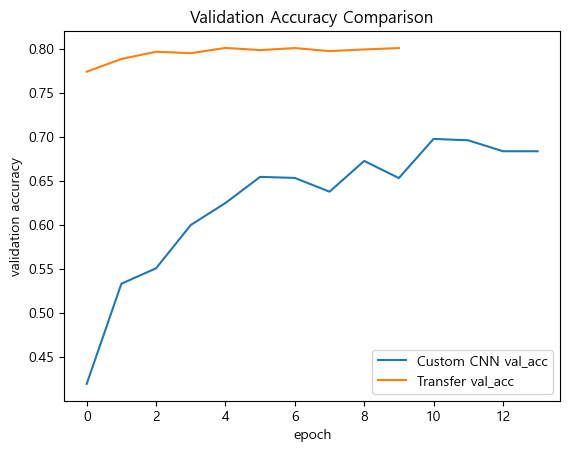

In [15]:
plt.plot(history1.history['val_accuracy'], label='Custom CNN val_acc')
plt.plot(history2.history['val_accuracy'], label='Transfer val_acc')
plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()

#### loss 비교

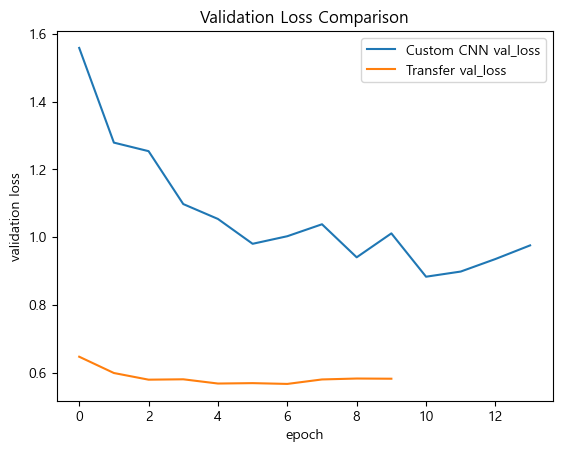

In [16]:
plt.plot(history1.history['val_loss'], label='Custom CNN val_loss')
plt.plot(history2.history['val_loss'], label='Transfer val_loss')
plt.xlabel('epoch')
plt.ylabel('validation loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()

---

#### 평가
- 커스텀 CNN : accuracy가 계속 올라가다 0.7 후반 대에서 막힘, val_loss는 4-6 에폭부터 val_loss가 불안정해지는 며 후반부 과적합.
- 전이학습 : 초반부터 0.7~0.8로 시작해 기본 뼈대가 잘 잡혀 있으나 학습률 상승은 더딤. 하지만 에폭 횟수가 너무 적어 patience를 좀 더 길게 잡고 지켜볼 필요가 있음.